In [10]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings
import cellrank
import moscot

In [11]:
# Read input file
working_directory = "RNA Sequencing Data/"
adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'manual_root', 'manual_end', 'sde_velocity_pseudotime'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'log1p', 'neighbors', 'pca', 'sample_colors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_pca', 'X_umap', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'pred_s', 'pred_u', 'sde_velocity', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'


In [12]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

       'Cdc25c', 'Cdc45', 'Cdc6', 'Cdca2', 'Cdca3', 'Cdca7', 'Cdca8', 'Chaf1b',
       'Ckap2', 'Ckap5', 'Cks1b', 'Cks2', 'Clspn', 'Ctcf', 'Dlgap5', 'Dscc1',
       'Dtl', 'E2f8', 'Exo1', 'Fen1', 'G2e3', 'Gins2', 'Gmnn', 'Gtse1',
       'Hjurp', 'Hn1', 'Kif23', 'Kif2c', 'Lbr', 'Mcm2', 'Mcm4', 'Mcm5', 'Mcm6',
       'Mlf1ip', 'Msh2', 'Ncapd2', 'Ndc80', 'Nek2', 'Nuf2', 'Pcna', 'Pola1',
       'Pold3', 'Prim1', 'Psrc1', 'Rad51', 'Rad51ap1', 'Rangap1', 'Rfc2',
       'Rpa2', 'Rrm1', 'Slbp', 'Smc4', 'Tacc3', 'Tipin', 'Tmpo', 'Ttk', 'Tyms',
       'Ube2c', 'Ubr7', 'Uhrf1', 'Ung', 'Usp1', 'Wdr76'],
      dtype='object')
       'Apaf1', 'Baiap2',
       ...
       'Tspyl2', 'Vamp8', 'Vdr', 'Vwa5a', 'Wrap73', 'Wwp1', 'Xpc', 'Zbtb16',
       'Zfp365', 'Zmat3'],
      dtype='object', length=134)


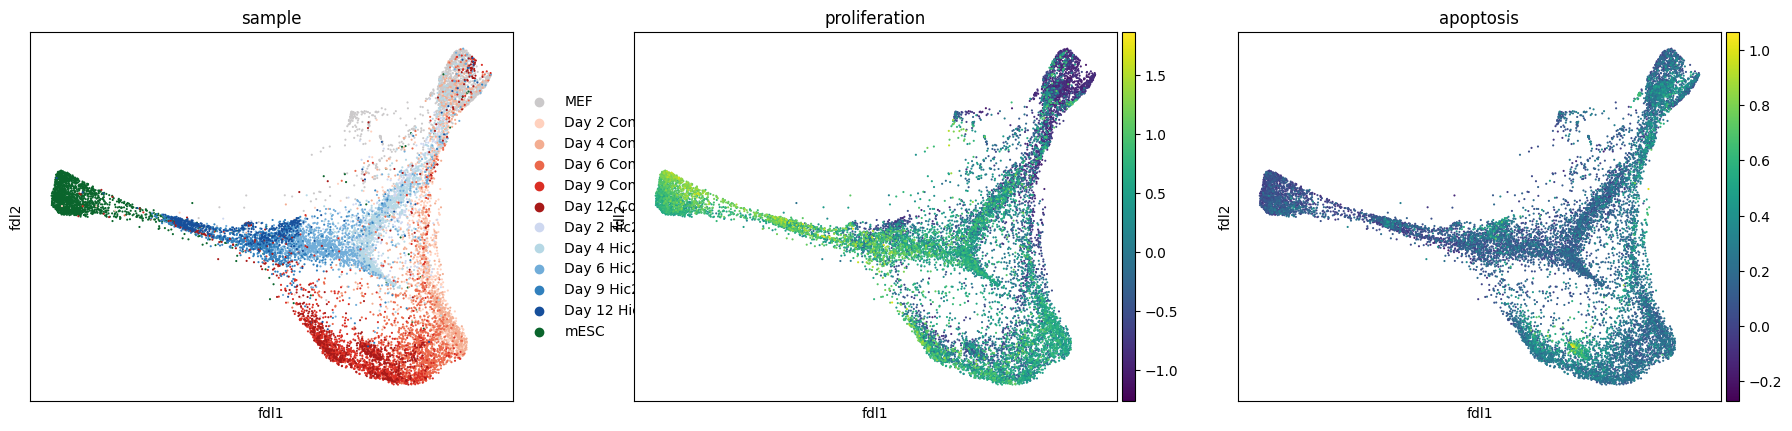

In [13]:
# Create real time kernel

temporal_problem = moscot.problems.time.TemporalProblem(adata)

# Adjust for cell growth and death
temporal_problem = temporal_problem.score_genes_for_marginals(
    gene_set_proliferation="mouse", gene_set_apoptosis="mouse"
)
scanpy.pl.embedding(
    adata, basis="fdl", color=["sample", "proliferation", "apoptosis"]
)

The next steps did not work because sdevelo requires numpy < 2 and jax requires numpy >= 2.

In [14]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="sde_velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

  0%|          | 0/12791 [00:00<?, ?cell/s]

VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344]

In [15]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [16]:
# Kernel based on gene expression similarity

connectivity_kernel = cellrank.kernels.ConnectivityKernel(adata)
connectivity_kernel.compute_transition_matrix()

ConnectivityKernel[n=12791, dnorm=True, key='connectivities']

In [120]:
# Combine all three kernels

combined_kernel = 0.34*velocity_kernel + 0.33*latent_time_kernel + 0.33*connectivity_kernel
combined_kernel.compute_transition_matrix()

(0.34 * VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344] + 0.33 * PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.33 * ConnectivityKernel[n=12791, dnorm=True, key='connectivities'])

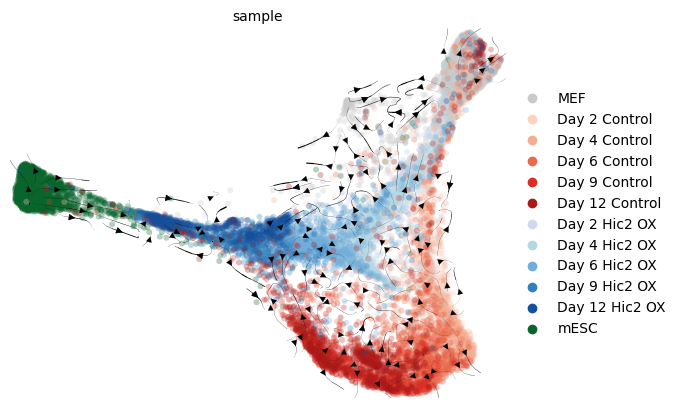

In [121]:
# Plot transition matrix
combined_kernel.plot_projection(basis="fdl", color="sample", legend_loc="right margin")

  0%|          | 0/100 [00:00<?, ?sim/s]

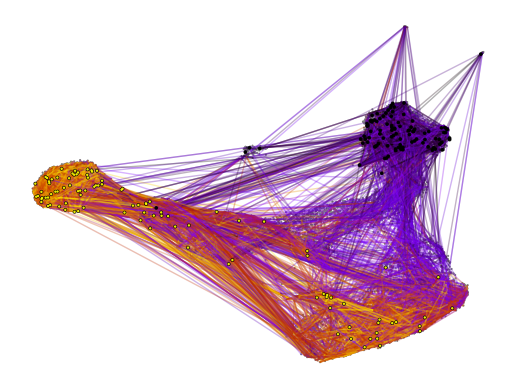

In [122]:
# Simulate random walk

combined_kernel.plot_random_walks(start_ixs={"sample": "MEF"}, max_iter=200, seed=0)

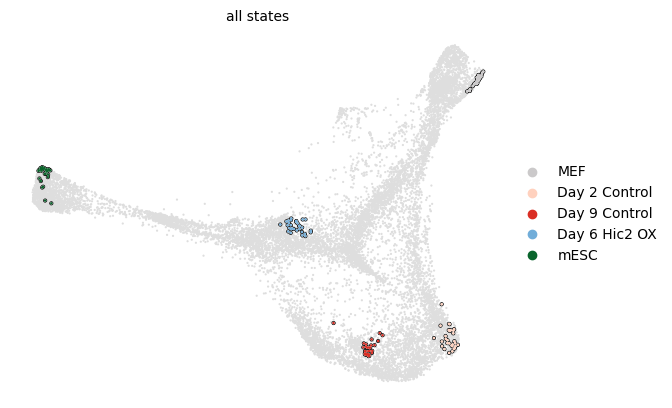

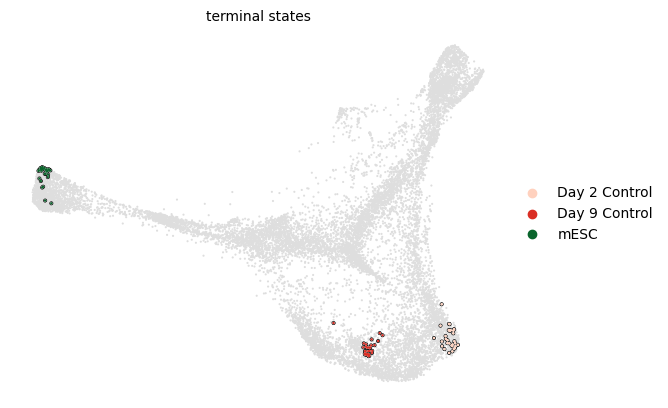

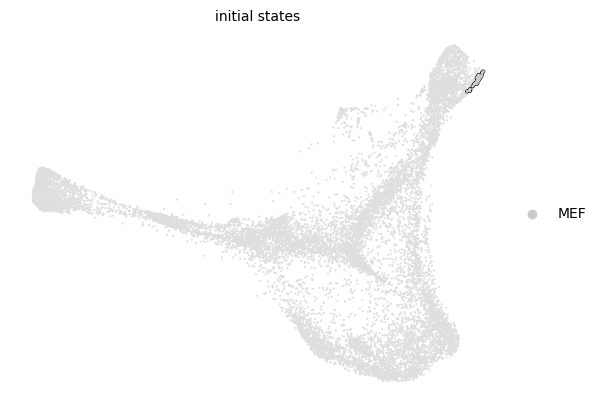

In [127]:
# Create an estimator and cluster automatically

gpcca = cellrank.estimators.GPCCA(0.5*velocity_kernel+0.5*latent_time_kernel)
gpcca.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
gpcca.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = gpcca.macrostates_memberships.names

# Predict terminal states

gpcca.predict_terminal_states()
gpcca.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = gpcca.terminal_states_memberships.names

# Predict initial states

gpcca.predict_initial_states()
gpcca.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

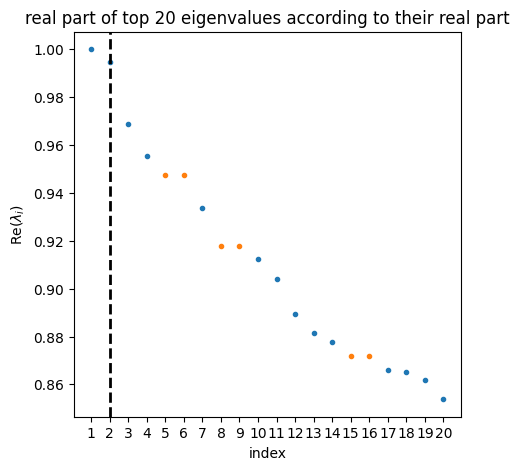

In [19]:
# More advanced estimator

estimator = cellrank.estimators.GPCCA(0.34*velocity_kernel+0.33*latent_time_kernel+0.33*connectivity_kernel)
estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

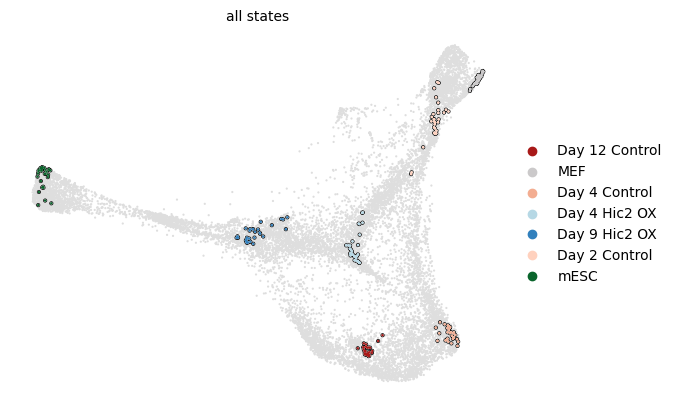

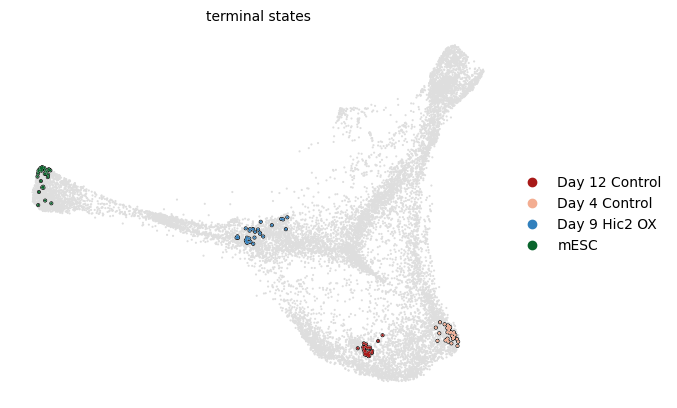

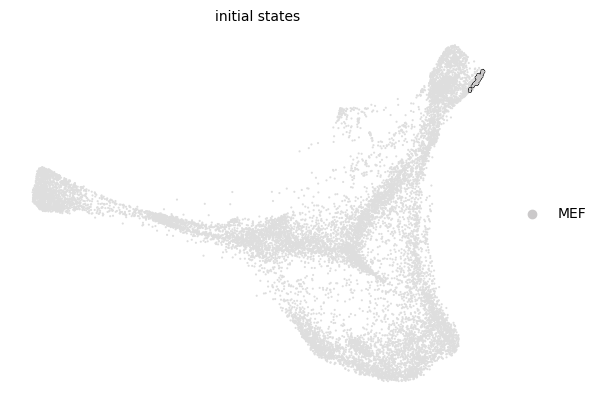

In [ ]:
# Cluster

estimator.compute_macrostates(n_states=7, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states

estimator.predict_terminal_states()
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states

estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)
initial_states = estimator.initial_states_memberships.names

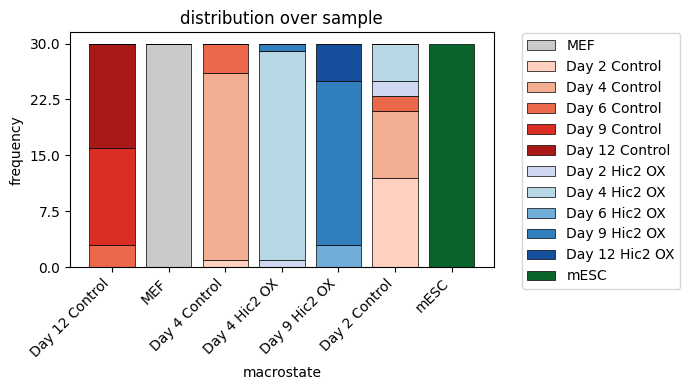

In [21]:
estimator.plot_macrostate_composition(key="sample", figsize=(7, 4))

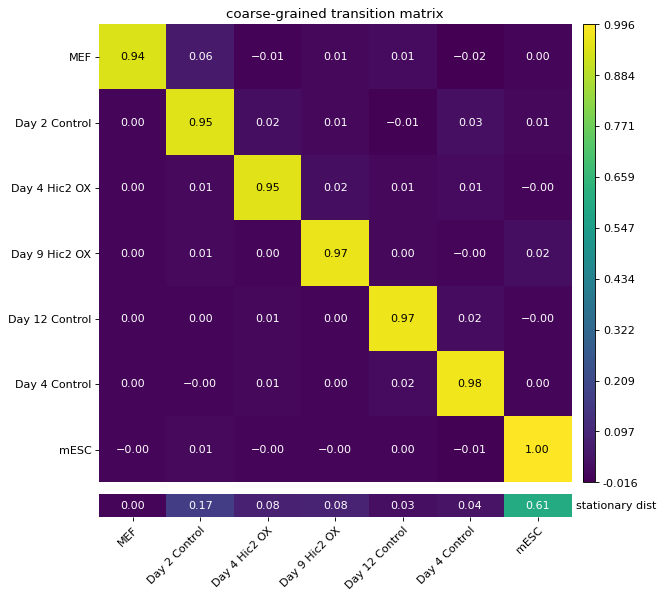

In [22]:
estimator.plot_coarse_T()

  0%|          | 0/4 [00:00<?, ?/s]

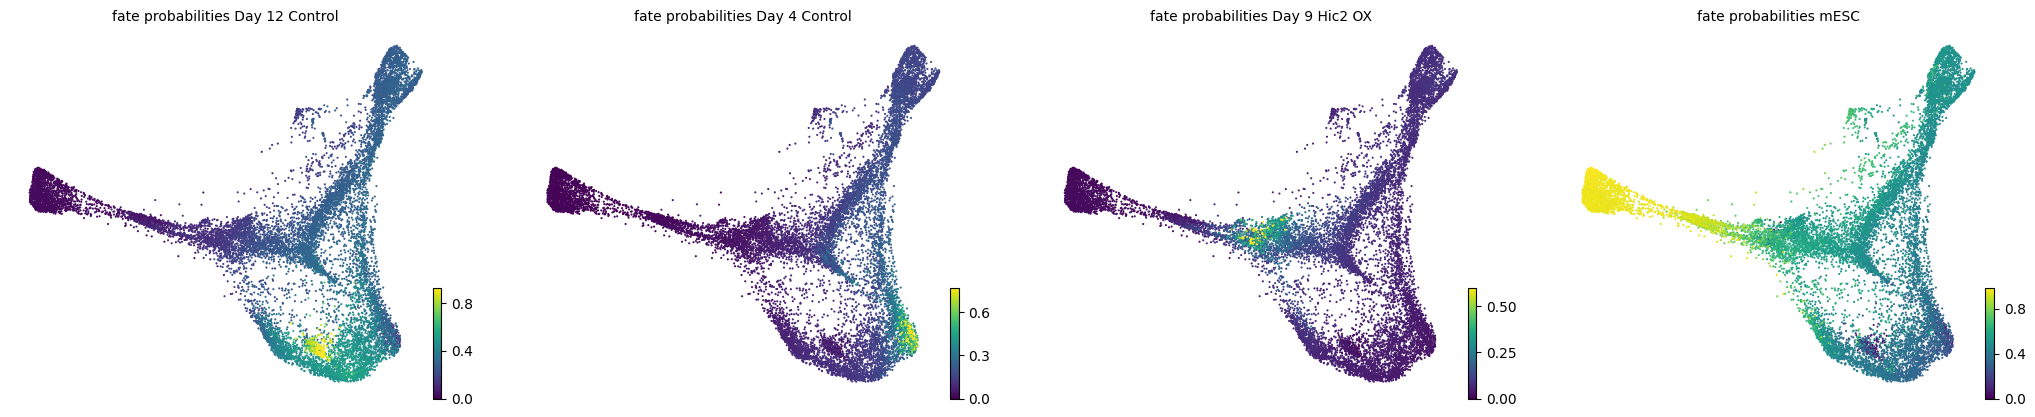

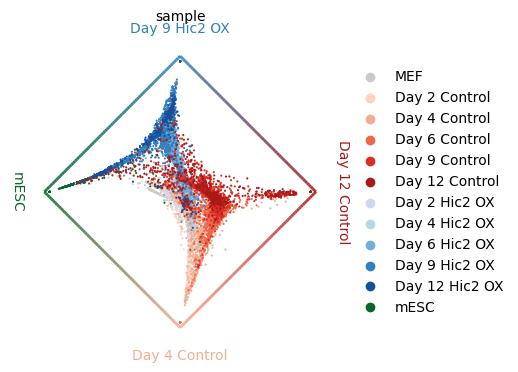

In [112]:
# Estimate fate probabilities

estimator.compute_fate_probabilities()

# Add fate probabilities to adata
for terminal_state in terminal_states:
    adata.obs[f"fate_probabilities_{terminal_state}"] = estimator.fate_probabilities[terminal_state].X.flatten()

estimator.plot_fate_probabilities(same_plot=False, basis="fdl")
cellrank.pl.circular_projection(adata, keys=["sample"], legend_loc="right")

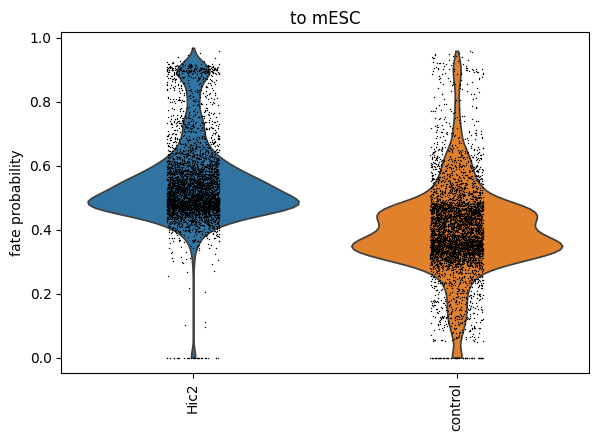

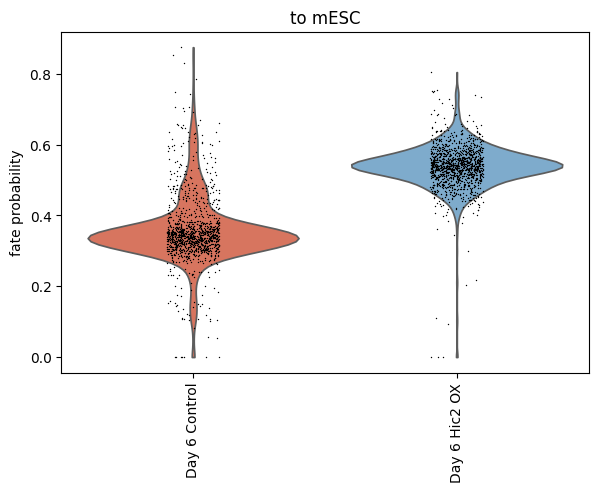

In [25]:
# Aggregate fate probabilities

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="sample",
    clusters=["Day 6 Control", "Day 6 Hic2 OX"],
)

In [70]:
# Find driver genes for all terminal states

reprogramming_groups = ["Hic2", "control"]

driver_df = estimator.compute_lineage_drivers(
    cluster_key="group", clusters=reprogramming_groups
)
corr_columns = [state+"_corr" for state in terminal_states]


In [71]:
# Drivers for mESCs
driver_df.sort_values("mESC_corr", ascending=False).head(20)[corr_columns]

,Day 12 Control_corr,Day 4 Control_corr,Day 9 Hic2 OX_corr,mESC_corr
gene_names,,,,
Dppa5a,-0.398345,-0.276941,-0.098819,0.620466
Trap1a,-0.452978,-0.319893,0.065149,0.614033
Utf1,-0.461665,-0.397645,0.196393,0.605958
Apoc1,-0.475916,-0.352672,0.181475,0.596164
Tet1,-0.377598,-0.330576,0.003210,0.583547
Rbpms2,-0.524415,-0.335489,0.269323,0.582947
Dppa4,-0.447403,-0.369790,0.185118,0.579220
Dnmt3l,-0.472187,-0.345548,0.197878,0.578931
Zfp42,-0.315864,-0.448805,0.062781,0.575546


In [75]:
# Drivers for Hic2 path
driver_df.sort_values("Day 9 Hic2 OX_corr", ascending=False).head(20)[corr_columns]

,Day 12 Control_corr,Day 4 Control_corr,Day 9 Hic2 OX_corr,mESC_corr
gene_names,,,,
Car2,-0.351198,-0.459792,0.534392,0.364141
Folr1,-0.490218,-0.407590,0.521154,0.466020
Mdk,-0.514133,-0.360890,0.514487,0.459714
Fgfbp1,-0.379898,-0.408366,0.500882,0.373434
Ifi27,-0.469435,-0.306596,0.495330,0.390164
Ifi27l2a,-0.339735,-0.237576,0.457195,0.240439
Fxyd6,-0.406819,-0.306453,0.445086,0.357934
Cotl1,-0.382010,-0.240640,0.426753,0.298698
Anxa2,-0.256058,-0.233722,0.415547,0.181197


In [80]:
# Drivers for early control path
driver_df.sort_values("Day 4 Control_corr", ascending=False).head(20)[corr_columns]

,Day 12 Control_corr,Day 4 Control_corr,Day 9 Hic2 OX_corr,mESC_corr
gene_names,,,,
Ccnd2,0.299870,0.563446,-0.356024,-0.483134
Fkbp11,0.205511,0.559569,-0.305709,-0.418433
Tspo,0.016749,0.530390,-0.246372,-0.252040
Ankrd13b,0.254988,0.517384,-0.294807,-0.441616
Fxyd5,-0.016083,0.511180,-0.203700,-0.230584
Ccdc109b,0.080849,0.508887,-0.236198,-0.302964
Fabp5,0.310257,0.492063,-0.317297,-0.464108
Pla2g12a,0.310037,0.486625,-0.363197,-0.435581
Kdelr3,0.051617,0.483769,-0.200235,-0.277225


In [92]:
# Drivers for late control path
driver_df.sort_values("Day 12 Control_corr", ascending=False).head(20)[corr_columns]

,Day 12 Control_corr,Day 4 Control_corr,Day 9 Hic2 OX_corr,mESC_corr
gene_names,,,,
Lgals7,0.646548,-0.066837,-0.295203,-0.405009
Cd24a,0.605624,0.318410,-0.436048,-0.558447
Aldh3a1,0.566316,-0.183670,-0.224596,-0.286106
Dkkl1,0.566082,-0.065040,-0.212016,-0.374928
Crb3,0.561901,-0.066208,-0.249444,-0.350152
Ly6g6c,0.558201,-0.169519,-0.247810,-0.275854
Lad1,0.544256,0.024662,-0.281670,-0.379345
Mal2,0.535604,-0.036588,-0.232103,-0.355207
Lmo1,0.534067,0.270310,-0.365109,-0.495565


In [118]:
# How specific genes correlate with terminal states
genes_of_interest = ["Krtdap", "Krt8", "Nanog", "Tet1", "Krt14", "Cdh1"]
driver_df.loc[genes_of_interest, corr_columns]

,Day 12 Control_corr,Day 4 Control_corr,Day 9 Hic2 OX_corr,mESC_corr
gene_names,,,,
Krtdap,0.165938,-0.103240,0.020141,-0.095513
Krt8,0.518494,-0.143086,-0.075746,-0.348825
Nanog,-0.217445,-0.277851,-0.012995,0.404690
Tet1,-0.377598,-0.330576,0.003210,0.583547
Krt14,0.292695,0.200967,-0.209185,-0.303385
Cdh1,0.394236,-0.144878,-0.218394,-0.154163


In [108]:
print(adata.obs.columns)

Index(['barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts',
       'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'initial_size_unspliced', 'initial_size_spliced', 'initial_size',
       'n_counts', 'latent_time', 'sde_velocity_self_transition',
       'manual_root', 'manual_end', 'sde_velocity_pseudotime', 'proliferation',
       'apoptosis', 'macrostates_fwd', 'clusters_gradients',
       'fate_probabilities_mESC', 'term_states_fwd', 'term_states_fwd_probs',
       'init_states_fwd', 'init_states_fwd_probs'],
      dtype='object')


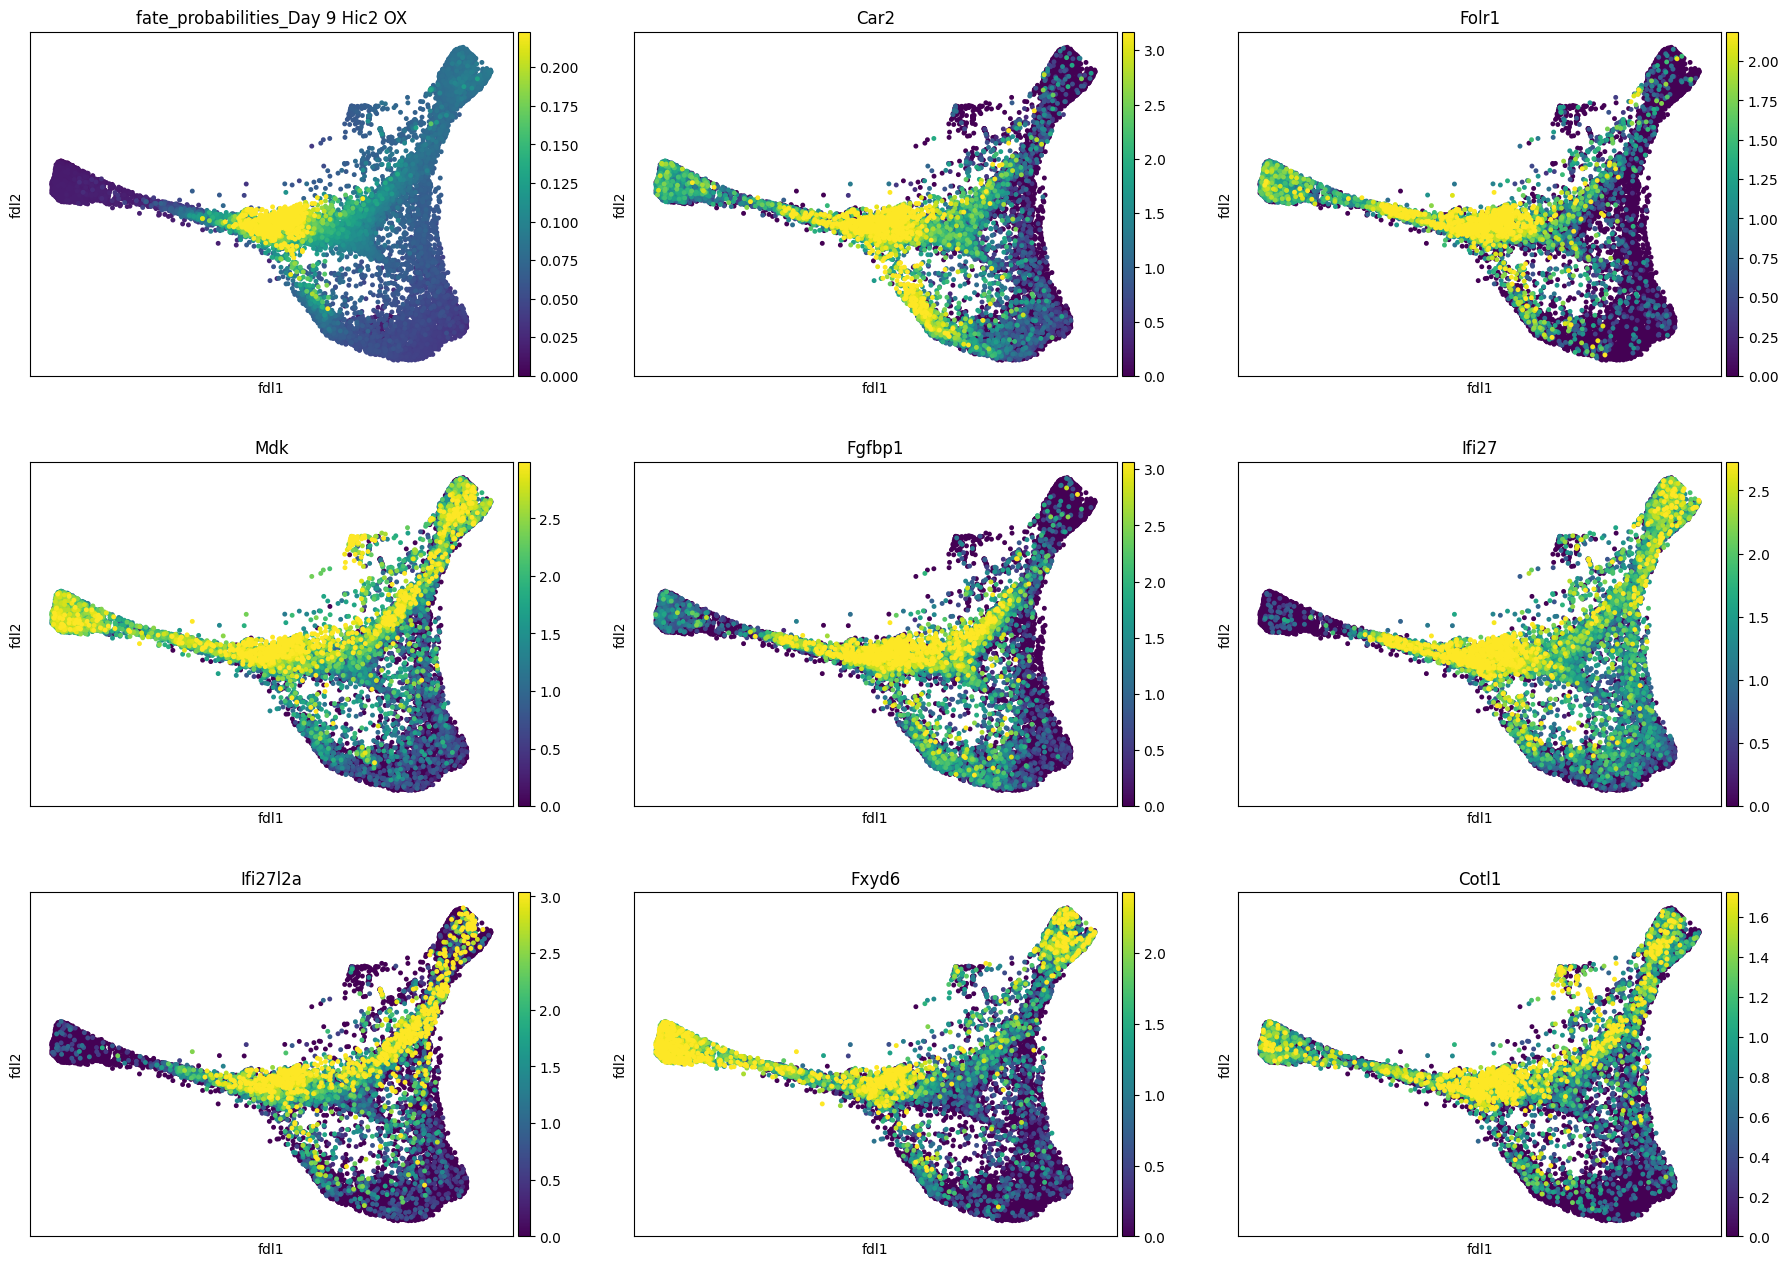

In [119]:
# Visualize driver genes for the Hic2 path

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["fate_probabilities_Day 9 Hic2 OX"] + list(driver_df.sort_values("Day 9 Hic2 OX_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

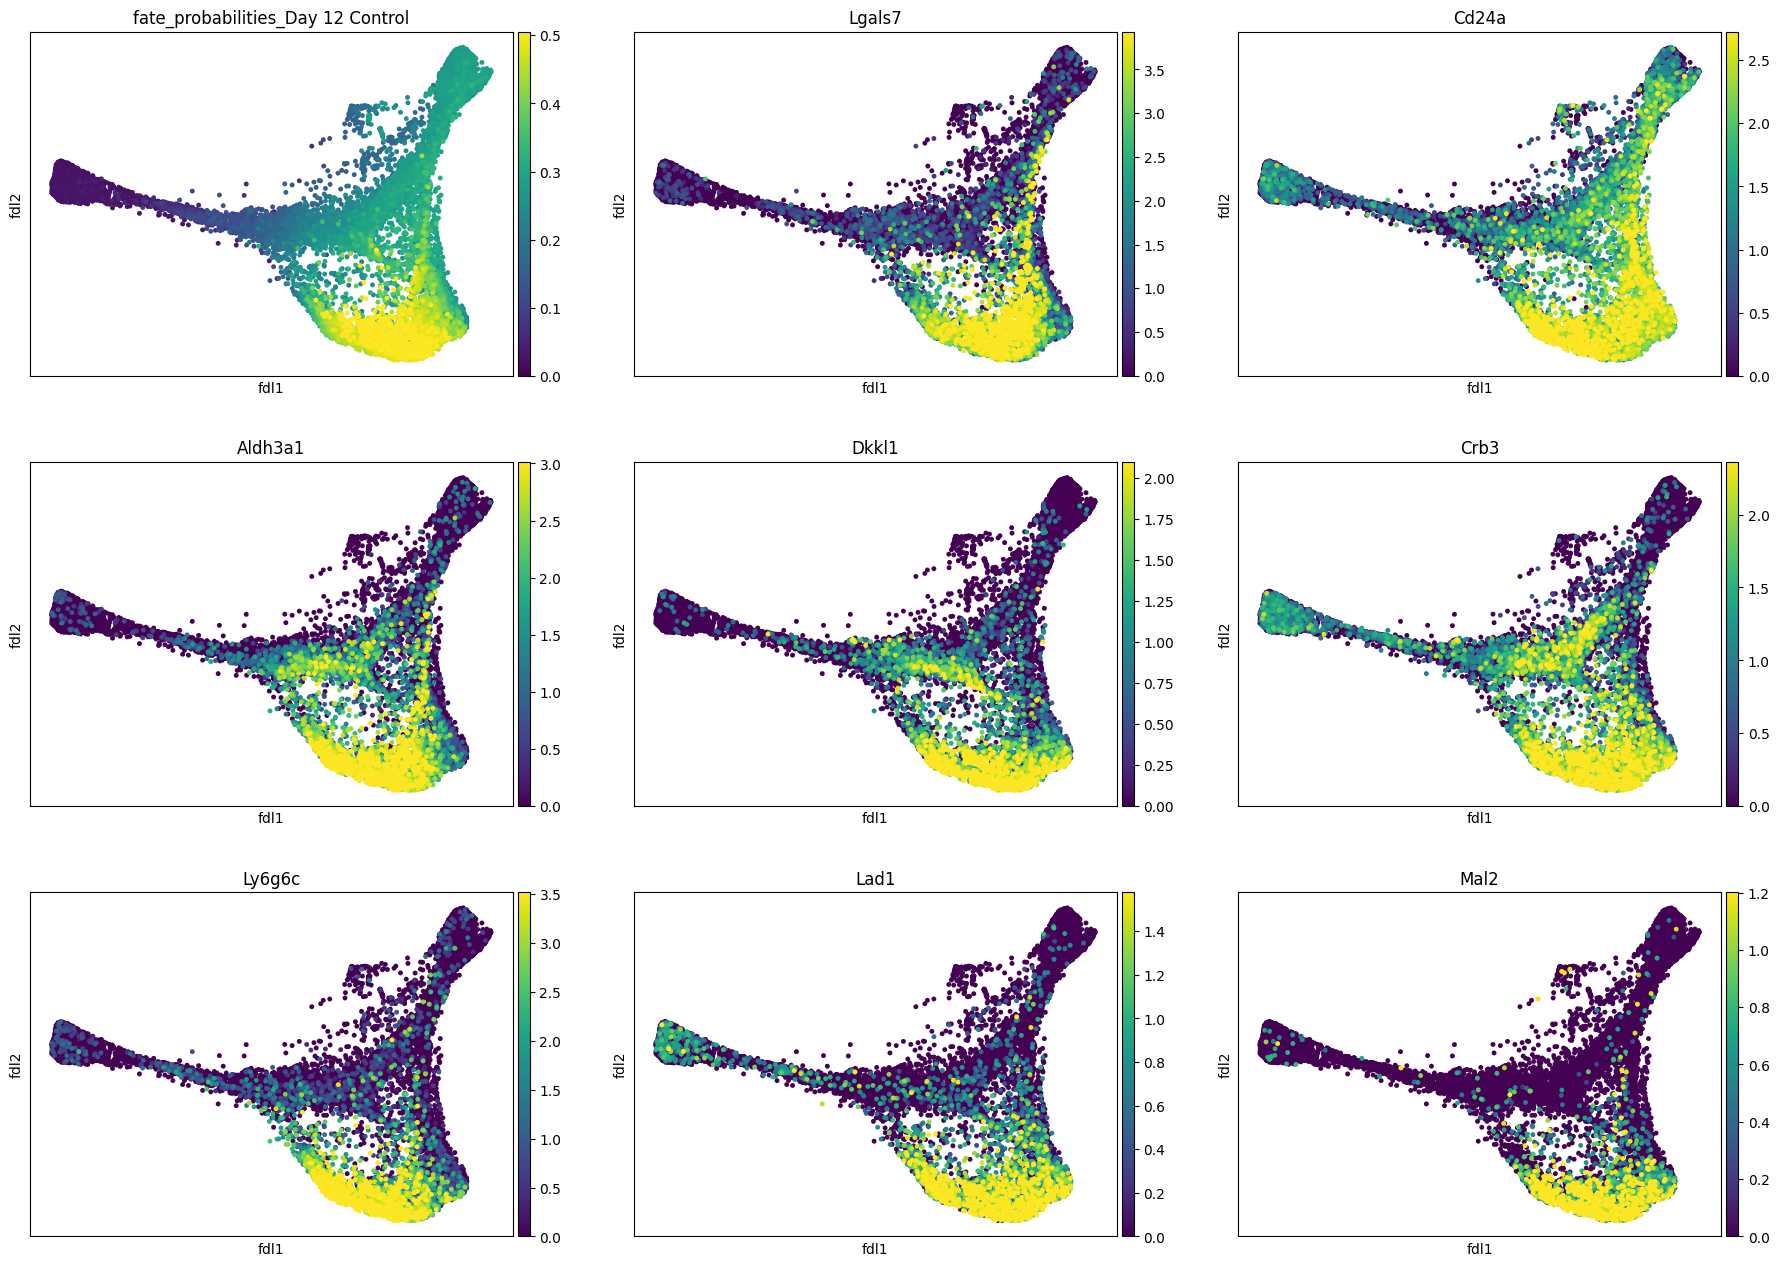

In [114]:
# Visualize driver genes for the control path

terminal_state = "Day 12 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)